# Predicting Presenteeism and Auditing Algorithmic Fairness in Korean Workers

Explainable machine-learning prediction of **presenteeism** (working while sick) from the **7th Korean Working Conditions Survey (2023)**, with an **algorithmic-fairness audit** across vulnerable worker groups.  
*Paper 2 — KSCI 2026.* Runs on **Google Colab** or locally; prints all results to screen and saves a timestamped copy to `output/run_<timestamp>/`.

In [1]:
# === Cell 1 · Setup & environment ============================================
import os
for _v in ("OMP_NUM_THREADS","OPENBLAS_NUM_THREADS","MKL_NUM_THREADS","NUMEXPR_NUM_THREADS"): os.environ[_v]="1"
os.environ["PYTHONHASHSEED"]="0"
import numpy as np, pandas as pd, random, warnings, datetime as dt
warnings.filterwarnings("ignore"); random.seed(0); np.random.seed(0)
import matplotlib, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, roc_curve, confusion_matrix
from sklearn.calibration import calibration_curve
try:
    from IPython.display import display
except Exception: display=print
try:
    import shap
except Exception:
    import subprocess,sys; subprocess.run([sys.executable,"-m","pip","install","-q","shap"]); import shap
CAND=[]
try:
    from google.colab import drive; drive.mount("/content/drive")
    CAND.append("/content/drive/MyDrive/완석_구글자료/연구자료/20260313_kosha/4. 제주학술대회/컴퓨터정보_논문2")
except Exception: pass
CAND += ["/Users/y3korea/Library/CloudStorage/GoogleDrive-y3korea@gmail.com/내 드라이브/완석_구글자료/연구자료/20260313_kosha/4. 제주학술대회/컴퓨터정보_논문2", os.getcwd()]
BASE=next((p for p in CAND if os.path.exists(os.path.join(p,"input"))), CAND[-1])
INP=os.path.join(BASE,"input","(데이터) 2023년 제7차 근로환경조사.csv")
TS=dt.datetime.now().strftime("%Y%m%d_%H%M%S"); OUT=os.path.join(BASE,"output","run_"+TS); os.makedirs(OUT,exist_ok=True)
print("BASE:",BASE); print("DATA found:",os.path.exists(INP)); print("OUTPUT:",OUT)
plt.rcParams.update({"font.family":"DejaVu Sans","font.size":9,"axes.linewidth":0.8,"savefig.dpi":300,"savefig.bbox":"tight",
 "axes.spines.top":False,"axes.spines.right":False,"figure.dpi":110,"axes.titlesize":10})
PAL=["#3b82c4","#e08214","#41ab5d","#d6604d","#8073ac","#56b4e9"]
def save(fig,n): fig.savefig(os.path.join(OUT,n+".png")); fig.savefig(os.path.join(OUT,n+".pdf"))

BASE: /Users/y3korea/Library/CloudStorage/GoogleDrive-y3korea@gmail.com/내 드라이브/완석_구글자료/연구자료/20260313_kosha/4. 제주학술대회/컴퓨터정보_논문2
DATA found: True
OUTPUT: /Users/y3korea/Library/CloudStorage/GoogleDrive-y3korea@gmail.com/내 드라이브/완석_구글자료/연구자료/20260313_kosha/4. 제주학술대회/컴퓨터정보_논문2/output/run_20260607_201144


In [2]:
# === Cell 2 · Load data, define target (presenteeism) and features =========
PHY=[f"hazard_phy{i}" for i in range(1,10)];ERG=[f"hazard_erg{i}" for i in range(1,7)];PSY=[f"hazard_psy{i}" for i in range(1,4)];HAZ=PHY+ERG+PSY
need=HAZ+["heal_wsick1","age","gender","occ","ind","emp_type","emp_stat","wtime_week","earning2_r","edu","comp_sizea_r"]
df=pd.read_csv(INP,encoding="utf-8-sig",usecols=lambda c:c.strip() in need,low_memory=False); df.columns=[c.strip() for c in df.columns]
df=df[(df.age>=15)&(df.age<=69)].copy(); df=df[df.heal_wsick1.isin([1,2])].copy()
df["y"]=(df.heal_wsick1==1).astype(int)                      # presenteeism: worked while sick
for c in HAZ: df[c]=df[c].where(df[c].between(1,7)); df[c]=8-df[c]
df["wtime_week"]=pd.to_numeric(df.wtime_week,errors="coerce")
df["earning2_r"]=df.earning2_r.where(df.earning2_r.between(1,9)); df["edu"]=df.edu.where(df.edu.between(1,7))
df["comp_sizea_r"]=df.comp_sizea_r.where(df.comp_sizea_r.between(1,12))
df["emp_stat"]=pd.to_numeric(df.emp_stat,errors="coerce"); df["emp_type"]=pd.to_numeric(df.emp_type,errors="coerce")
print(f"Analytic sample N={len(df):,} | presenteeism prevalence {df.y.mean()*100:.2f}%")
NUM=HAZ+["age","wtime_week","earning2_r","edu","comp_sizea_r"]; CAT=["gender","emp_type","occ","ind"]
for c in CAT: df[c]=df[c].astype("object")
X=df[NUM+CAT]; y=df.y.values
pre=ColumnTransformer([("num",Pipeline([("imp",SimpleImputer(strategy="median")),("sc",StandardScaler())]),NUM),
                       ("cat",Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("oh",OneHotEncoder(handle_unknown="ignore"))]),CAT)])
Xtr,Xte,ytr,yte,itr,ite=train_test_split(X,y,np.arange(len(df)),test_size=0.30,stratify=y,random_state=0)
print("train",len(Xtr),"test",len(Xte),"| features:",len(NUM),"numeric +",len(CAT),"categorical")

Analytic sample N=36,574 | presenteeism prevalence 6.69%
train 25601 test 10973 | features: 23 numeric + 4 categorical


,CV_AUC,CV_sd,Test_AUC,PR_AUC,Brier
Logistic Regression,0.6949,0.0204,0.6857,0.1452,0.2145
Random Forest,0.7241,0.0133,0.7174,0.2047,0.0585
HistGradientBoosting,0.7152,0.0192,0.7025,0.1660,0.1838


Best model: Random Forest


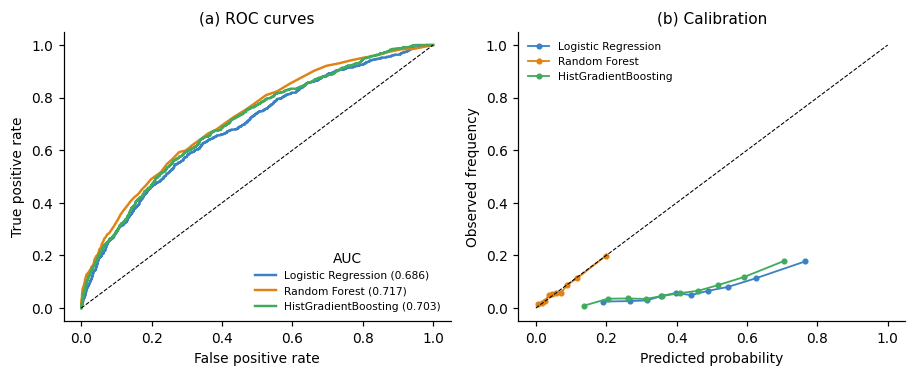

In [3]:
# === Cell 3 · Benchmark classifiers (handle class imbalance) ===============
models={"Logistic Regression":LogisticRegression(max_iter=2000,class_weight="balanced",n_jobs=-1),
        "Random Forest":RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=0,n_jobs=-1),
        "HistGradientBoosting":HistGradientBoostingClassifier(class_weight="balanced",random_state=0)}
cv=StratifiedKFold(5,shuffle=True,random_state=0); rows={}; prob={}; fitted={}
for nm,clf in models.items():
    pipe=Pipeline([("pre",pre),("clf",clf)]); acv=cross_val_score(pipe,Xtr,ytr,cv=cv,scoring="roc_auc",n_jobs=-1)
    pipe.fit(Xtr,ytr); p=pipe.predict_proba(Xte)[:,1]; prob[nm]=p; fitted[nm]=pipe
    rows[nm]=dict(CV_AUC=acv.mean(),CV_sd=acv.std(),Test_AUC=roc_auc_score(yte,p),PR_AUC=average_precision_score(yte,p),Brier=brier_score_loss(yte,p))
perf=pd.DataFrame(rows).T; perf.to_csv(os.path.join(OUT,"table1_performance.csv")); display(perf.round(4)); best=perf.Test_AUC.idxmax(); print("Best model:",best)
fig,ax=plt.subplots(1,2,figsize=(8.4,3.5))
for i,nm in enumerate(models):
    fpr,tpr,_=roc_curve(yte,prob[nm]); ax[0].plot(fpr,tpr,lw=1.6,color=PAL[i],label=f"{nm} ({rows[nm]['Test_AUC']:.3f})")
ax[0].plot([0,1],[0,1],"k--",lw=0.7); ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate"); ax[0].set_title("(a) ROC curves"); ax[0].legend(fontsize=7,frameon=False,title="AUC")
for i,nm in enumerate(models):
    fr,mp=calibration_curve(yte,prob[nm],n_bins=10,strategy="quantile"); ax[1].plot(mp,fr,"o-",ms=3,lw=1.2,color=PAL[i],label=nm)
ax[1].plot([0,1],[0,1],"k--",lw=0.7); ax[1].set_xlabel("Predicted probability"); ax[1].set_ylabel("Observed frequency"); ax[1].set_title("(b) Calibration"); ax[1].legend(fontsize=7,frameon=False)
fig.tight_layout(); save(fig,"fig1_performance"); plt.show()

,mean |SHAP|
Painful postures,0.040490
Heavy loads,0.029277
Weekly hours,0.028503
Age,0.024289
Emot. disturbing,0.019714
Loud noise,0.018620
High temperature,0.017499
Education,0.013499
Lifting people,0.012872
Sex=1,0.009551


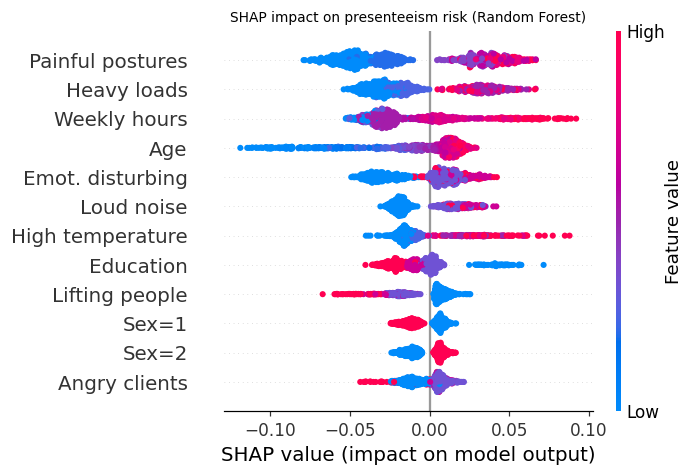

In [4]:
# === Cell 4 · Explainability — SHAP (lightweight RF) ======================
LBLH={"hazard_phy1":"Vibration","hazard_phy2":"Loud noise","hazard_phy3":"High temperature","hazard_phy4":"Low temperature","hazard_phy5":"Fumes/dust","hazard_phy6":"Solvent vapours","hazard_phy7":"Chemicals(skin)","hazard_phy8":"Secondhand smoke","hazard_phy9":"Infectious mat.","hazard_erg1":"Painful postures","hazard_erg2":"Lifting people","hazard_erg3":"Heavy loads","hazard_erg4":"Standing","hazard_erg5":"Sitting","hazard_erg6":"Repetitive mov.","hazard_psy1":"Handling customers","hazard_psy2":"Angry clients","hazard_psy3":"Emot. disturbing","age":"Age","wtime_week":"Weekly hours","earning2_r":"Income","edu":"Education","comp_sizea_r":"Company size"}
def pretty(f):
    b=f.split("__",1)[1] if "__" in f else f
    return LBLH.get(b,b.replace("gender_","Sex=").replace("emp_type_","Emp=").replace("occ_","Occ=").replace("ind_","Ind="))
rf_s=Pipeline([("pre",pre),("clf",RandomForestClassifier(n_estimators=120,max_depth=12,min_samples_leaf=40,class_weight="balanced",random_state=0,n_jobs=-1))]).fit(Xtr,ytr)
feat=rf_s.named_steps["pre"].get_feature_names_out()
Xt=rf_s.named_steps["pre"].transform(Xte); Xt=Xt.toarray() if hasattr(Xt,"toarray") else Xt
samp=np.random.RandomState(0).choice(Xt.shape[0],min(800,Xt.shape[0]),replace=False)
sv=shap.TreeExplainer(rf_s.named_steps["clf"]).shap_values(Xt[samp],check_additivity=False)
sv1=sv[1] if isinstance(sv,list) else (sv[:,:,1] if getattr(sv,"ndim",2)==3 else sv)
imp=pd.Series(np.abs(sv1).mean(0),index=[pretty(f) for f in feat]).sort_values(ascending=False); imp.to_csv(os.path.join(OUT,"table_shap_importance.csv"))
display(imp.head(12).rename("mean |SHAP|").to_frame())
Xs=pd.DataFrame(Xt[samp],columns=[pretty(f) for f in feat])
plt.figure(); shap.summary_plot(sv1,Xs,max_display=12,show=False,plot_size=(6.4,4.4))
plt.title("SHAP impact on presenteeism risk (Random Forest)",fontsize=9); plt.tight_layout()
plt.savefig(os.path.join(OUT,"fig2_shap.png")); plt.savefig(os.path.join(OUT,"fig2_shap.pdf")); plt.show()

In [5]:
# === Cell 5 · Algorithmic fairness audit across vulnerable groups =========
pb=prob[best]; fr,tp,th=roc_curve(yte,pb); thr=th[np.argmax(tp-fr)]
d=df.iloc[ite].copy(); d["yt"]=yte; d["pb"]=pb; d["yp"]=(pb>=thr).astype(int)
d["Sex"]=d.gender.map({1:"Male",2:"Female"})
d["Age group"]=pd.cut(d.age,[14,29,39,49,59,69],labels=["15-29","30-39","40-49","50-59","60-69"])
def emp3(r):
    if r.emp_type==3 and r.emp_stat==1: return "Wage-regular"
    if r.emp_type==3 and r.emp_stat in (2,3): return "Wage-precarious"
    return "Self-employed"
d["Employment"]=d.apply(emp3,axis=1); d["Education"]=pd.cut(d.edu,[0,3,5,7],labels=["≤Middle","High/College","University+"])
AX=["Sex","Age group","Employment","Education"]
def gm(s):
    yt,yp,pp=s.yt.values,s.yp.values,s.pb.values; auc=roc_auc_score(yt,pp) if len(np.unique(yt))>1 else np.nan
    tn,fp,fn,tpv=confusion_matrix(yt,yp,labels=[0,1]).ravel()
    return dict(n=len(s),prev=yt.mean()*100,AUC=auc,TPR=tpv/(tpv+fn) if tpv+fn else np.nan,FPR=fp/(fp+tn) if fp+tn else np.nan,Selection=yp.mean()*100)
tabs={ax:pd.DataFrame({g:gm(s) for g,s in d.groupby(ax) if len(s)>30}).T for ax in AX}
gaps=[]
for ax in AX:
    t=tabs[ax]; gaps.append(dict(Attribute=ax,k=len(t),AUC_gap=t.AUC.max()-t.AUC.min(),TPR_gap=t.TPR.max()-t.TPR.min(),FPR_gap=t.FPR.max()-t.FPR.min(),EqOdds=(t.TPR.max()-t.TPR.min())+(t.FPR.max()-t.FPR.min()),DemParity=(t.Selection.max()-t.Selection.min())/100))
gapdf=pd.DataFrame(gaps); gapdf.to_csv(os.path.join(OUT,"table2_fairness_gaps.csv"),index=False); pd.concat(tabs).round(4).to_csv(os.path.join(OUT,"table2_fairness_bygroup.csv"))
print(f"Operating threshold (Youden J) = {thr:.3f}")
for ax in AX: print("\n["+ax+"]"); display(tabs[ax].round(3))
print("\nFairness gaps (larger = more unfair):"); display(gapdf.round(3))

Operating threshold (Youden J) = 0.080

[Sex]


,n,prev,AUC,TPR,FPR,Selection
Female,5784.0,6.898,0.725,0.602,0.282,30.411
Male,5189.0,6.456,0.708,0.582,0.273,29.331



[Age group]


,n,prev,AUC,TPR,FPR,Selection
15-29,856.0,3.738,0.644,0.219,0.080,8.528
30-39,1805.0,4.820,0.660,0.356,0.159,16.842
40-49,2239.0,5.404,0.717,0.545,0.248,26.396
50-59,3203.0,6.993,0.706,0.634,0.338,35.904
60-69,2870.0,9.408,0.722,0.700,0.375,40.523



[Employment]


,n,prev,AUC,TPR,FPR,Selection
Self-employed,4118.0,8.208,0.714,0.695,0.386,41.136
Wage-precarious,1191.0,5.374,0.779,0.641,0.226,24.853
Wage-regular,5664.0,5.862,0.700,0.479,0.212,22.793



[Education]


,n,prev,AUC,TPR,FPR,Selection
≤Middle,784.0,14.031,0.706,0.800,0.562,59.566
High/College,6593.0,6.750,0.712,0.616,0.309,33.005
University+,3590.0,4.930,0.687,0.401,0.166,17.716



Fairness gaps (larger = more unfair):


,Attribute,k,AUC_gap,TPR_gap,FPR_gap,EqOdds,DemParity
0,Sex,2,0.017,0.019,0.009,0.028,0.011
1,Age group,5,0.078,0.481,0.295,0.776,0.320
2,Employment,3,0.079,0.216,0.174,0.390,0.183
3,Education,3,0.025,0.399,0.397,0.796,0.419


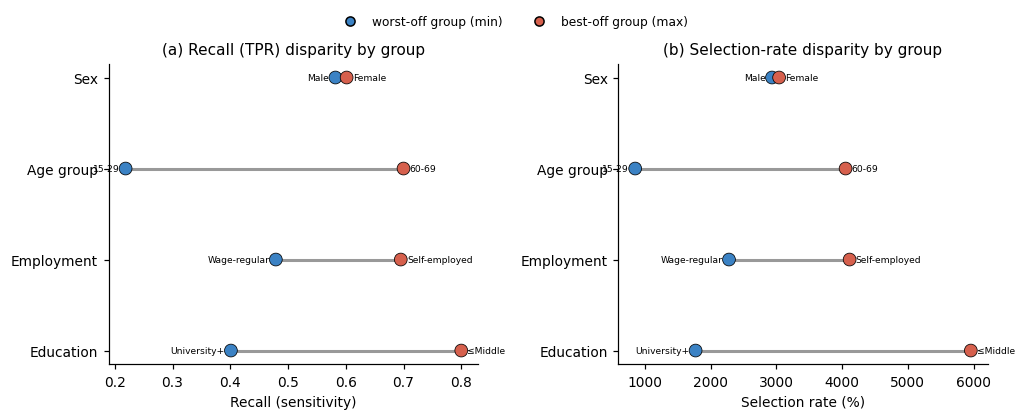

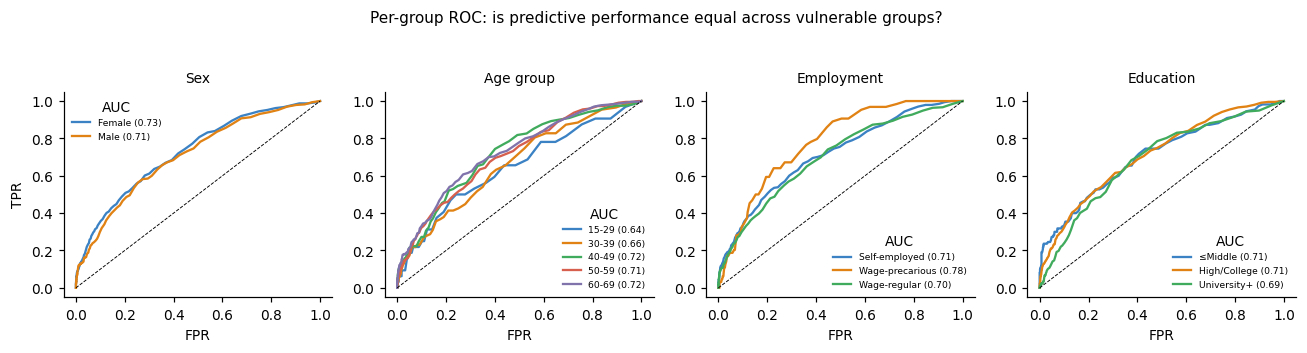

In [6]:
# === Cell 6 · Fairness visualisation — disparity dumbbell + per-group ROC ==
fig,ax=plt.subplots(1,2,figsize=(9.4,3.6))
for j,(metric,ttl,xl) in enumerate([("TPR","(a) Recall (TPR) disparity by group","Recall (sensitivity)"),("Selection","(b) Selection-rate disparity by group","Selection rate (%)")]):
    for i,axn in enumerate(AX):
        t=tabs[axn]; v=t[metric].values; lo,hi=v.min(),v.max()   # Selection is already in % (gm returns yp.mean()*100)
        ax[j].plot([lo,hi],[i,i],"-",color="0.6",lw=2,zorder=1); ax[j].scatter([lo,hi],[i,i],s=70,color=[PAL[0],PAL[3]],zorder=2,edgecolor="k",lw=0.5)
        ax[j].annotate(str(t[metric].idxmin()),(lo,i),fontsize=6,ha="right",va="center",xytext=(-4,0),textcoords="offset points")
        ax[j].annotate(str(t[metric].idxmax()),(hi,i),fontsize=6,ha="left",va="center",xytext=(4,0),textcoords="offset points")
    ax[j].set_yticks(range(len(AX))); ax[j].set_yticklabels(AX); ax[j].invert_yaxis(); ax[j].set_title(ttl); ax[j].set_xlabel(xl)
fig.legend(handles=[Line2D([0],[0],marker="o",ls="",mfc=PAL[0],mec="k",label="worst-off group (min)"),Line2D([0],[0],marker="o",ls="",mfc=PAL[3],mec="k",label="best-off group (max)")],loc="upper center",ncol=2,frameon=False,fontsize=8,bbox_to_anchor=(0.5,1.06))
fig.tight_layout(); save(fig,"fig3_fairness_dumbbell"); plt.show()

fig,ax=plt.subplots(1,4,figsize=(12,3.0))
for a,axn in zip(ax,AX):
    for i,(g,s) in enumerate([(g,s) for g,s in d.groupby(axn) if len(s)>30]):
        if s.yt.nunique()<2: continue
        f_,t_,_=roc_curve(s.yt,s.pb); a.plot(f_,t_,lw=1.5,color=PAL[i%len(PAL)],label=f"{g} ({roc_auc_score(s.yt,s.pb):.2f})")
    a.plot([0,1],[0,1],"k--",lw=0.6); a.set_title(axn,fontsize=9); a.set_xlabel("FPR"); a.legend(fontsize=6,frameon=False,title="AUC")
ax[0].set_ylabel("TPR"); fig.suptitle("Per-group ROC: is predictive performance equal across vulnerable groups?",y=1.05,fontsize=10)
fig.tight_layout(); save(fig,"fig4_group_roc"); plt.show()

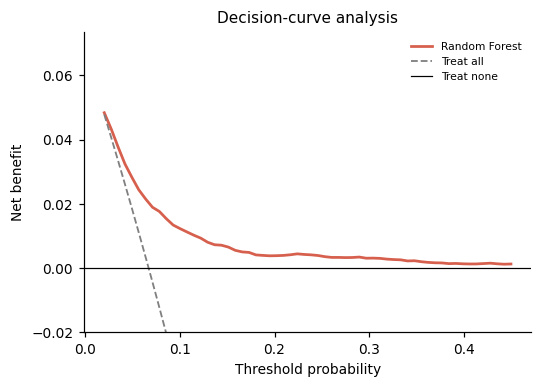

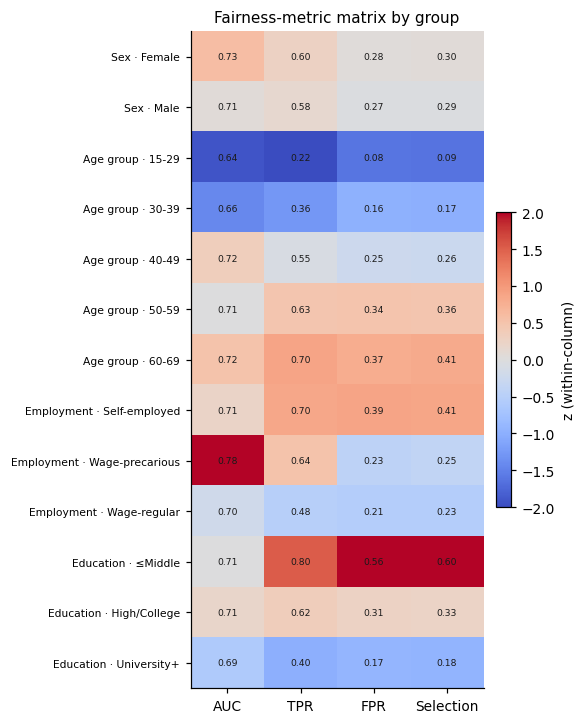

Saved to: /Users/y3korea/Library/CloudStorage/GoogleDrive-y3korea@gmail.com/내 드라이브/완석_구글자료/연구자료/20260313_kosha/4. 제주학술대회/컴퓨터정보_논문2/output/run_20260607_201144
Files: ['_summary.txt', 'fig1_performance.pdf', 'fig1_performance.png', 'fig2_shap.pdf', 'fig2_shap.png', 'fig3_fairness_dumbbell.pdf', 'fig3_fairness_dumbbell.png', 'fig4_group_roc.pdf', 'fig4_group_roc.png', 'fig5_decision_curve.pdf', 'fig5_decision_curve.png', 'fig6_disparity_heatmap.pdf', 'fig6_disparity_heatmap.png', 'table1_performance.csv', 'table2_fairness_bygroup.csv', 'table2_fairness_gaps.csv', 'table_shap_importance.csv']


In [7]:
# === Cell 7 · Decision-curve analysis + disparity matrix + manifest =======
def nb(y,p,pt):
    yp=(p>=pt).astype(int); n=len(y); tp=((yp==1)&(y==1)).sum(); fp=((yp==1)&(y==0)).sum(); return tp/n-fp/n*(pt/(1-pt))
pts=np.linspace(0.02,0.45,60); prev=yte.mean()
fig,ax=plt.subplots(figsize=(5.0,3.6))
ax.plot(pts,[nb(yte,pb,t) for t in pts],lw=1.8,color=PAL[3],label=best)
ax.plot(pts,[prev-(1-prev)*(t/(1-t)) for t in pts],lw=1.2,color="0.5",ls="--",label="Treat all"); ax.axhline(0,color="k",lw=0.8,label="Treat none")
ax.set_ylim(-0.02,prev*1.1); ax.set_xlabel("Threshold probability"); ax.set_ylabel("Net benefit"); ax.set_title("Decision-curve analysis"); ax.legend(fontsize=7,frameon=False)
fig.tight_layout(); save(fig,"fig5_decision_curve"); plt.show()

allg=pd.concat({ax:tabs[ax][["AUC","TPR","FPR","Selection"]] for ax in AX}); allg["Selection"]=allg["Selection"]/100
fig,axh=plt.subplots(figsize=(5.4,0.42*len(allg)+1.2)); Mn=(allg-allg.mean())/allg.std()
im=axh.imshow(Mn.values,aspect="auto",cmap="coolwarm",vmin=-2,vmax=2)
axh.set_xticks(range(4)); axh.set_xticklabels(["AUC","TPR","FPR","Selection"]); axh.set_yticks(range(len(allg))); axh.set_yticklabels([f"{a} · {g}" for a,g in allg.index],fontsize=7)
for i in range(len(allg)):
    for j in range(4): axh.text(j,i,f"{allg.iloc[i,j]:.2f}",ha="center",va="center",fontsize=6,color="0.1")
fig.colorbar(im,ax=axh,fraction=0.046,pad=0.04,label="z (within-column)"); axh.set_title("Fairness-metric matrix by group"); fig.tight_layout(); save(fig,"fig6_disparity_heatmap"); plt.show()

with open(os.path.join(OUT,"_summary.txt"),"w") as f:
    f.write(f"N={len(df)}; presenteeism={df.y.mean()*100:.2f}%; best={best}; AUC={perf.Test_AUC.max():.3f}; thr={thr:.3f}\n\n")
    f.write(perf.round(4).to_string()+"\n\n"+gapdf.round(3).to_string(index=False))
print("Saved to:",OUT); print("Files:",sorted(os.listdir(OUT)))